##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [ ]:

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from PIL import Image

In [5]:
from transformers import AutoImageProcessor, AutoModel

MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)

model.eval()

print(f"Model loaded on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model loaded on cuda


In [ ]:

pet_dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    download=True
)

print("Dataset size:", len(pet_dataset))
print("Number of classes:", len(pet_dataset.classes))
print(pet_dataset.classes)

100%|██████████| 792M/792M [00:29<00:00, 26.4MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.6MB/s]


Dataset size: 3680
Number of classes: 37
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [ ]:

cat_breeds = [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian Mau", "Maine Coon", "Persian", "Ragdoll",
    "Russian Blue", "Siamese", "Sphynx"
]

cat_indices = []
dog_indices = []

for i in range(len(pet_dataset)):
    img, label = pet_dataset[i]
    class_name = pet_dataset.classes[label]

    if class_name in cat_breeds and len(cat_indices) < 10:
        cat_indices.append(i)
    elif class_name not in cat_breeds and len(dog_indices) < 10:
        dog_indices.append(i)

    if len(cat_indices) == 10 and len(dog_indices) == 10:
        break

selected_indices = cat_indices + dog_indices

print("Cats selected:", len(cat_indices))
print("Dogs selected:", len(dog_indices))
print("Total selected:", len(selected_indices))

Cats selected: 10
Dogs selected: 10
Total selected: 20


In [ ]:

features = []
true_labels = []
images = []

for idx in selected_indices:
    img, label = pet_dataset[idx]
    class_name = pet_dataset.classes[label]

    img = img.convert("RGB")
    images.append(img)

    if class_name in cat_breeds:
        true_labels.append(0)   # cat
    else:
        true_labels.append(1)   # dog

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    cls_token = outputs.last_hidden_state[:, 0, :]
    cls_token = F.normalize(cls_token, p=2, dim=1)

    features.append(cls_token.cpu().numpy()[0])

features = np.array(features)
true_labels = np.array(true_labels)

print("Feature shape:", features.shape)
print("True labels:", true_labels)

Feature shape: (20, 384)
True labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features)

print("Predicted cluster labels:", cluster_labels)

Predicted cluster labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [ ]:
mapped_labels = np.zeros_like(cluster_labels)

for cluster in [0, 1]:
    indices = np.where(cluster_labels == cluster)[0]
    majority_label = np.bincount(true_labels[indices]).argmax()
    mapped_labels[indices] = majority_label

print("Mapped predicted labels:", mapped_labels)
print("True labels:", true_labels)

Mapped predicted labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
True labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        10
         Dog       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



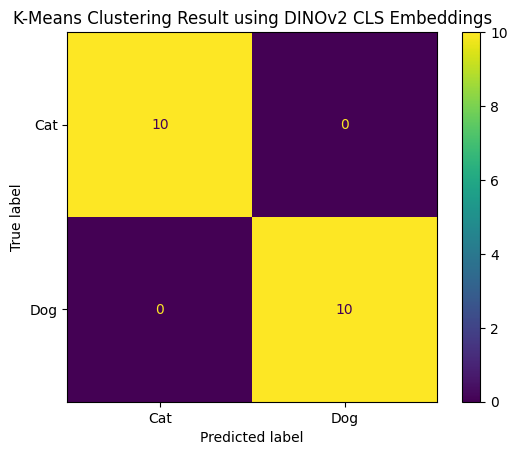

In [ ]:

print(classification_report(
    true_labels,
    mapped_labels,
    target_names=["Cat", "Dog"]
))

cm = confusion_matrix(true_labels, mapped_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()
plt.title("K-Means Clustering Result using DINOv2 CLS Embeddings")
plt.show()

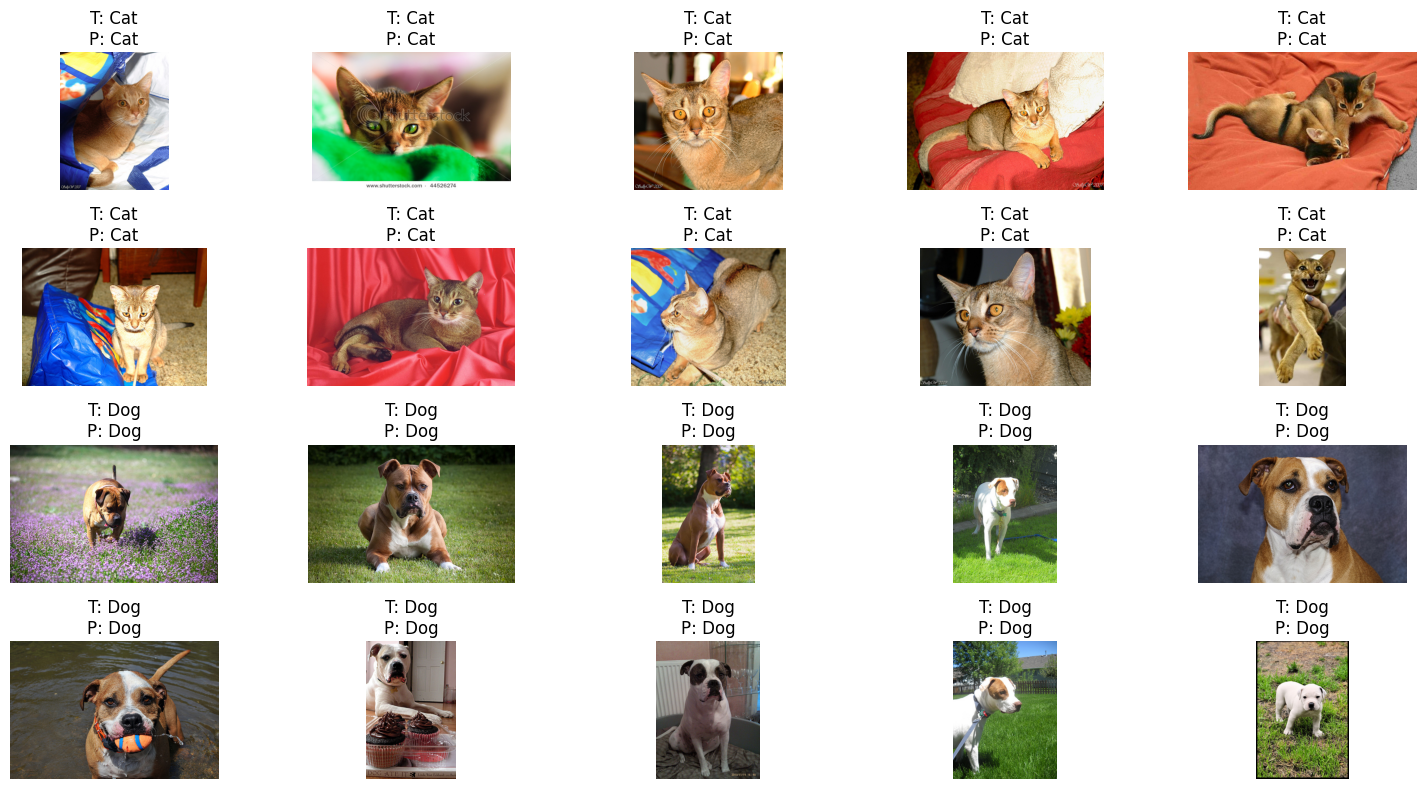

In [11]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(images):
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    true_name = "Cat" if true_labels[i] == 0 else "Dog"
    pred_name = "Cat" if mapped_labels[i] == 0 else "Dog"

    plt.title(f"T: {true_name}\nP: {pred_name}")

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [ ]:

import torch
import requests
from PIL import Image
from io import BytesIO
from transformers import AutoImageProcessor, AutoModelForImageClassification

In [ ]:

CLASSIFICATION_MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

classification_processor = AutoImageProcessor.from_pretrained(CLASSIFICATION_MODEL_ID)
classification_model = AutoModelForImageClassification.from_pretrained(CLASSIFICATION_MODEL_ID).to(device)

classification_model.eval()

print(f"Classification model loaded on {device}")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Classification model loaded on cuda


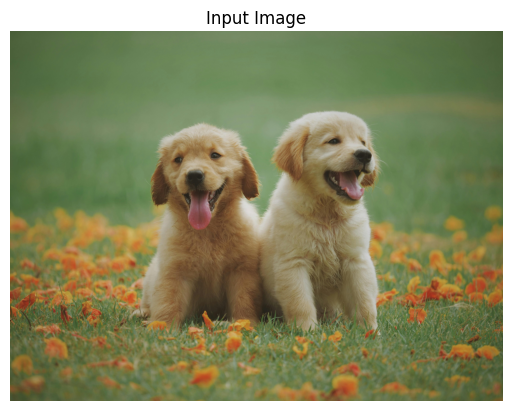

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

image_url = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"

response = requests.get(image_url, headers={"User-Agent": "Mozilla/5.0"})
response.raise_for_status()

test_image = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(test_image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [ ]:
inputs = classification_processor(images=test_image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = classification_model(**inputs)

logits = outputs.logits
probs = torch.softmax(logits, dim=1)

top5 = torch.topk(probs, k=5)

print("Top-5 Predictions:")

for score, class_id in zip(top5.values[0], top5.indices[0]):
    label = classification_model.config.id2label[class_id.item()]
    confidence = score.item() * 100
    print(f"{label}: {confidence:.2f}%")

Top-5 Predictions:
golden retriever: 95.35%
standard poodle: 1.73%
Labrador retriever: 0.80%
kuvasz: 0.51%
chow, chow chow: 0.22%


In [ ]:
predicted_class_id = probs.argmax(dim=1).item()
predicted_label = classification_model.config.id2label[predicted_class_id]
confidence = probs[0, predicted_class_id].item() * 100

print("Final Prediction:")
print(f"Class: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")

Final Prediction:
Class: golden retriever
Confidence: 95.35%
